<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/piuminda/resnet50_waste_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow keras numpy pandas matplotlib seaborn scikit-learn opencv-python

In [2]:
!pip install kaggle

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json


{}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d techsash/waste-classification-data -p "/content/drive/MyDrive/4thyear/DL/assignment"

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [6]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data.zip"
extract_path = "/content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data"


In [7]:
# Unzip only if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset unzipped successfully.")
else:
    print("✅ Dataset already extracted.")

✅ Dataset already extracted.


In [8]:
dataset_path = "/content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET"

In [9]:
train_path = os.path.join(dataset_path, "TRAIN")
test_path = os.path.join(dataset_path, "TEST")

print("Dataset Base Path:", dataset_path)
print("Train Folder:", train_path)
print("Test Folder:", test_path)


Dataset Base Path: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET
Train Folder: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET/TRAIN
Test Folder: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET/TEST


In [10]:
def explore_dataset(path):
    print("\n📂 Dataset Structure:")
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Show first 5 files only
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

explore_dataset(dataset_path)


📂 Dataset Structure:
DATASET/
  TEST/
    O/
      O_12969.jpg
      O_12970.jpg
      O_12971.jpg
      O_12972.jpg
      O_12973.jpg
      ... and 1396 more files
    R/
      R_10112.jpg
      R_10113.jpg
      R_10114.jpg
      R_10115.jpg
      R_10116.jpg
      ... and 1107 more files
  TRAIN/
    O/
      O_9099.jpg
      O_91.jpg
      O_910.jpg
      O_9100.jpg
      O_9101.jpg
      ... and 12560 more files
    R/
      R_9099.jpg
      R_91.jpg
      R_910.jpg
      R_9100.jpg
      R_9101.jpg
      ... and 9994 more files


In [11]:
# Count images per class
train_path = os.path.join(dataset_path, "TRAIN")
test_path = os.path.join(dataset_path, "TEST")

train_organic = len(os.listdir(os.path.join(train_path, "O")))
train_recyclable = len(os.listdir(os.path.join(train_path, "R")))
test_organic = len(os.listdir(os.path.join(test_path, "O")))
test_recyclable = len(os.listdir(os.path.join(test_path, "R")))

print(f"\nTraining Set:")
print(f"Organic: {train_organic} images")
print(f"Recyclable: {train_recyclable} images")
print(f"Total Training: {train_organic + train_recyclable} images")

print(f"\nTest Set:")
print(f"Organic: {test_organic} images")
print(f"Recyclable: {test_recyclable} images")
print(f"Total Test: {test_organic + test_recyclable} images")


Training Set:
Organic: 12565 images
Recyclable: 9999 images
Total Training: 22564 images

Test Set:
Organic: 1401 images
Recyclable: 1112 images
Total Test: 2513 images


In [12]:
# Visualize sample images
def visualize_samples(path, class_names=['Organic', 'Recyclable']):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i, class_name in enumerate(['O', 'R']):
        class_path = os.path.join(path, class_name)
        images = os.listdir(class_path)[:5]

        for j, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i, j].imshow(img)
            axes[i, j].set_title(f'{class_names[i]} - {img_name}')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()



In [13]:
def analyze_image_dimensions(path):
    print("📊 Analyzing image dimensions from:", path)
    dimensions = []
    for class_name in ['O', 'R']:
        class_path = os.path.join(path, class_name)
        print("Checking folder:", class_path)
        if not os.path.exists(class_path):
            print("❌ Folder not found:", class_path)
            continue
        for img_name in os.listdir(class_path)[:100]:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                dimensions.append(img.shape)

    if len(dimensions) == 0:
        print("⚠️ No images found or loaded.")
        return

    dimensions = np.array(dimensions)
    print(f"\n✅ Image dimensions analysis:")
    print(f"Height: min={dimensions[:,0].min()}, max={dimensions[:,0].max()}, mean={dimensions[:,0].mean():.1f}")
    print(f"Width: min={dimensions[:,1].min()}, max={dimensions[:,1].max()}, mean={dimensions[:,1].mean():.1f}")
    print(f"Channels: {dimensions[:,2].max()}")

📊 Analyzing image dimensions from: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET/TRAIN
Checking folder: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET/TRAIN/O
Checking folder: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET/TRAIN/R

✅ Image dimensions analysis:
Height: min=80, max=383, mean=205.8
Width: min=51, max=600, mean=250.3
Channels: 3
🖼️ Visualizing samples from: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET/TRAIN
✅ Found 5 images in 'O'
✅ Found 5 images in 'R'


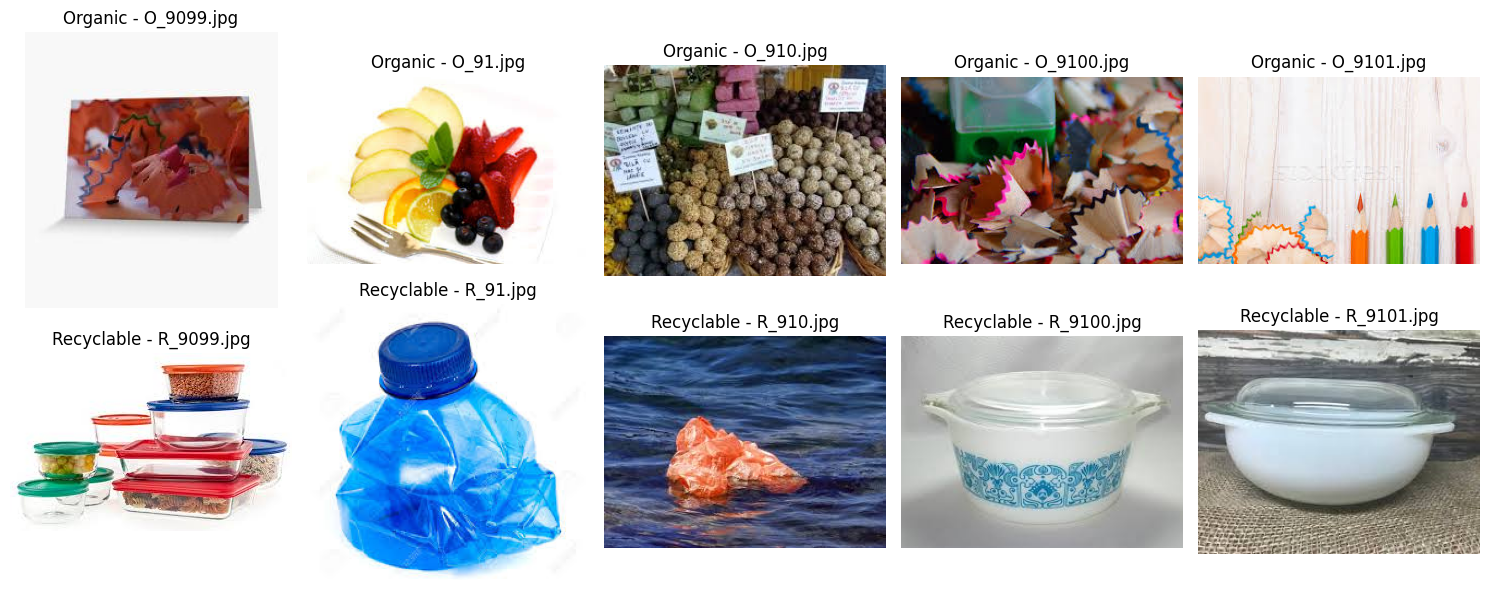

In [14]:
def visualize_samples(path, class_names=['Organic', 'Recyclable']):
    print("🖼️ Visualizing samples from:", path)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i, class_name in enumerate(['O', 'R']):
        class_path = os.path.join(path, class_name)
        if not os.path.exists(class_path):
            print(f"❌ Folder not found: {class_path}")
            continue
        images = os.listdir(class_path)[:5]
        print(f"✅ Found {len(images)} images in '{class_name}'")
        for j, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f'{class_names[i]} - {img_name}')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Run both
analyze_image_dimensions(train_path)
visualize_samples(train_path)

# ** Data Preprocessing & Augmentation**

In [16]:
# Data preprocessing parameters
IMG_SIZE = (224, 224)  # ResNet50 input size
BATCH_SIZE = 32

In [17]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest',
    validation_split=0.2  # Using 20% for validation
)

# Validation data (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Test data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Classes: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Classes: {'O': 0, 'R': 1}
Training samples: 18052
Validation samples: 4512
Test samples: 2513


# ResNet50 Model Implementation

In [18]:
def create_resnet50_model(input_shape=(224, 224, 3), num_classes=1):
    """
    Create ResNet50 model for waste classification
    """
    # Load pre-trained ResNet50 without top layers
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base model layers initially
    base_model.trainable = False

    # Add custom classification head
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs, outputs)

    return model, base_model

Create model

In [19]:
model, base_model = create_resnet50_model()

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# Display model architecture
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,776,577 (94.52 MB)

 Trainable params: 1,184,769 (4.52 MB)

 Non-trainable params: 23,591,808 (90.00 MB)